# Encontro 8 - Parte 2

## Relação entre variáveis e correlação

1. Uma breve revisão de **conceitos, princípios e dicas** do primeiro módulo - especialmente úteis para quem está chegando agora;
2. **Dúvidas, perguntas e problemas frequentes**;
3. **Seaborn e Matplotlib** para visualização de dados;
4. Outros assuntos menores que surgirem ao longo do encontro.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

### 1. Preparação dos dados

Vamos trabalhar novamente com o conjunto de dados **Gapminder**, que reúne informações sobre diferentes países ao longo do tempo.

Entre as variáveis disponíveis, utilizaremos:

- `lifeExp`: expectativa de vida;
- `gdpPercap`: PIB per capita;
- `pop`: população;
- `continent`: continente;
- `year`: ano da observação.

In [2]:
gapminder_df = pd.read_csv(
    "https://raw.githubusercontent.com/jhlopesalves/eda_humanidades/refs/heads/main/"
    "encontro_4/data/gapminderDataFiveYear.csv"
)

In [5]:
gapminder_df.sample(
    n=10,
    random_state=42,
)

,country,year,pop,continent,lifeExp,gdpPercap
1046,Myanmar,1962,23634436.0,Asia,45.108,388.000000
745,Ireland,1957,2878220.0,Europe,68.900,5599.077872
785,Jamaica,1977,2156814.0,Americas,70.110,6650.195573
367,Cote d'Ivoire,1987,10761098.0,Africa,54.655,2156.956069
1029,Morocco,1997,28529501.0,Africa,67.660,2982.101858
1648,Vietnam,1972,44655014.0,Asia,50.254,699.501644
259,Central African Republic,1987,2840009.0,Africa,50.485,844.876350
1509,Taiwan,1997,21628605.0,Asia,75.250,20206.820980
514,Ethiopia,2002,67946797.0,Africa,50.725,530.053532
1229,Poland,1977,34621254.0,Europe,70.670,9508.141454


### 2. Inspecionando o ambiente de execução (_namespace_)

Ao trabalhar em notebooks, o resultado de uma célula pode depender de código executado anteriormente. Variáveis, DataFrames, funções e outros objetos criados durante a sessão permanecem disponíveis no **ambiente de execução**, também chamado de *namespace*.

Esse comportamento ajuda a diagnosticar alguns erros frequentes.

Se Python indicar que um nome não foi encontrado, podemos verificar duas possibilidades comuns:

- o nome utilizado no código está diferente do nome com que o objeto foi criado;
- a célula responsável por criar aquele objeto ainda não foi executada na sessão atual.

No Colab e no Jupyter, o comando mágico `%whos` permite inspecionar os objetos disponíveis no ambiente:

```python
%whos
```

A saída apresenta, entre outras informações, o **nome** e o **tipo** dos objetos existentes naquele momento.

Diante de um erro relacionado a uma variável, podemos então formular uma pergunta concreta:

> **O objeto que estou tentando utilizar existe no ambiente de execução com esse nome?**

Essa verificação é especialmente útil para localizar erros de digitação e problemas relacionados à ordem de execução das células.

In [4]:
%whos

Variable       Type         Data/Info
-------------------------------------
gapminder_df   DataFrame    Shape: (1704, 6)
np             module       <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
pd             module       <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
plt            module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns            module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
stats          module       <module 'scipy.stats' fro<...>scipy/stats/__init__.py'>


### 3. Correlação paramétrica e não paramétrica

A distinção entre métodos **paramétricos** e **não paramétricos** depende das suposições utilizadas pelo procedimento estatístico e da forma como a informação presente nos dados é representada.

No contexto das correlações trabalhadas aqui, essa distinção ajuda a compreender a diferença entre **Pearson** e **Spearman**.

A correlação de Pearson trabalha diretamente com os valores observados e quantifica uma associação **linear**. A correlação de Spearman transforma os valores em **postos (*ranks*)** e quantifica uma associação **monotônica**.

Essa diferença será importante para interpretar a matriz de correlação que construiremos a seguir.

In [6]:
correlation_matrix = (
    gapminder_df
    .select_dtypes(include="number")
    .corr(method="spearman")
)

correlation_matrix.round(2)

,year,pop,lifeExp,gdpPercap
year,1.00,0.22,0.45,0.23
pop,0.22,1.00,0.18,0.05
lifeExp,0.45,0.18,1.00,0.83
gdpPercap,0.23,0.05,0.83,1.00


A matriz apresenta valores entre \(-1\) e \(1\):

- valores positivos indicam que postos maiores em uma variável tendem a acompanhar postos maiores na outra;
- valores negativos indicam que postos maiores em uma variável tendem a acompanhar postos menores na outra;
- valores próximos de zero indicam uma associação monotônica fraca.

A diagonal principal contém valores iguais a \(1\), pois cada variável apresenta correlação perfeita consigo mesma. A matriz também é **simétrica**: a correlação entre `lifeExp` e `gdpPercap`, por exemplo, é a mesma que entre `gdpPercap` e `lifeExp`.

### 4. Consultando a documentação do heatmap

Antes de construir o gráfico, podemos consultar a documentação da função que utilizaremos.

Para o heatmap:

In [7]:
help(sns.heatmap)

Help on function heatmap in module seaborn.matrix:

heatmap(
    data,
    *,
    vmin=None,
    vmax=None,
    cmap=None,
    center=None,
    robust=False,
    annot=None,
    fmt='.2g',
    annot_kws=None,
    linewidths=0,
    linecolor='white',
    cbar=True,
    cbar_kws=None,
    cbar_ax=None,
    square=False,
    xticklabels='auto',
    yticklabels='auto',
    mask=None,
    ax=None,
    **kwargs
)
    Plot rectangular data as a color-encoded matrix.

    This is an Axes-level function and will draw the heatmap into the
    currently-active Axes if none is provided to the ``ax`` argument.  Part of
    this Axes space will be taken and used to plot a colormap, unless ``cbar``
    is False or a separate Axes is provided to ``cbar_ax``.

    Parameters
    ----------
    data : rectangular dataset
        2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
        is provided, the index/column information will be used to label the
        columns and rows.
    v

Não há necessidade de memorizar todos os parâmetros disponíveis (a não ser que você queira...). 
Para esta visualização, alguns deles são particularmente úteis:

- `data`: dados representados no heatmap;
- `vmin`, `vmax` e `center`: limites e centro da escala de cores;
- `cmap`: paleta utilizada;
- `annot`: exibição dos valores dentro das células;
- `fmt`: formato numérico das anotações;
- `square`: formato das células;
- `linewidths`: separação visual entre as células;
- `cbar_kws`: configurações adicionais da barra de cores;
- `ax`: eixo do Matplotlib em que o gráfico será desenhado.

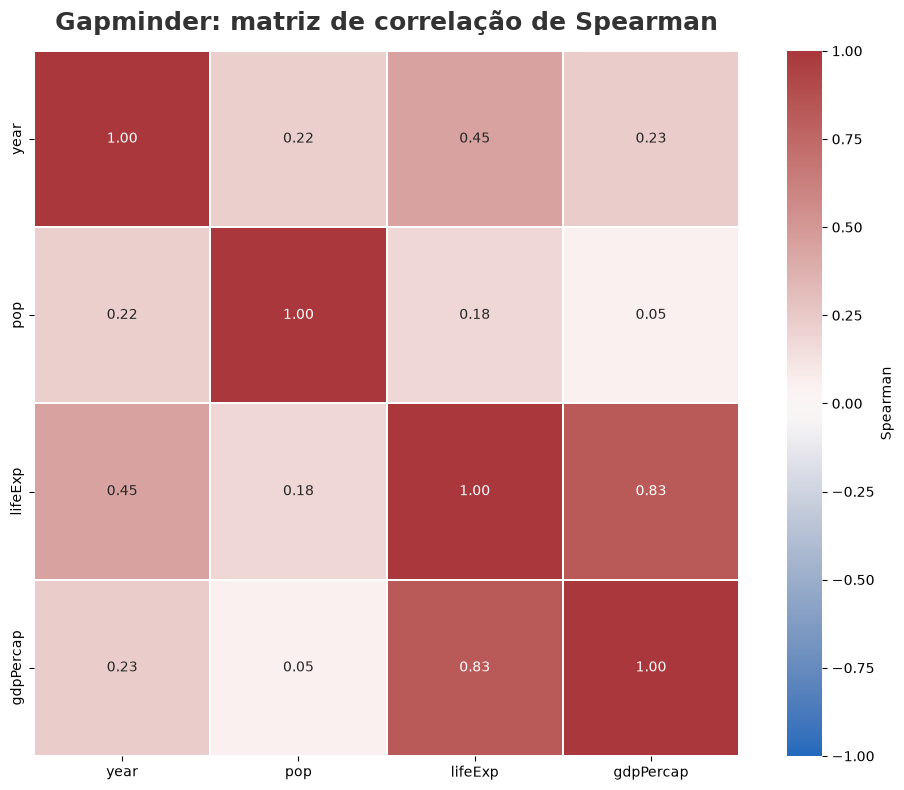

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    data=correlation_matrix,

    # Spearman varia de -1 a 1; zero fica no centro da escala de cores.
    vmin=-1,
    vmax=1,
    center=0,

    cmap="vlag",

    annot=True,
    fmt=".2f",

    square=True,
    linewidths=1.2,

    # cbar_kws recebe configurações específicas para a barra de cores.
    cbar_kws={
        "label": "Spearman",
    },

    ax=ax,
)

ax.set_title(
    label="Gapminder: matriz de correlação de Spearman",
    fontsize=18,
    fontweight="bold",
    color="#333333",
    pad=15,
)

plt.tight_layout()
plt.show()

### Interpretando o heatmap

O heatmap representa os mesmos coeficientes da matriz anterior utilizando duas formas de informação ao mesmo tempo:

- o **valor escrito em cada célula** mostra o coeficiente de correlação;
- a **cor** permite identificar rapidamente a direção e a intensidade da associação.

Como utilizamos uma escala centrada em zero e limitada entre \(-1\) e \(1\), correlações de magnitudes semelhantes recebem intensidades visuais comparáveis nos dois sentidos.

A visualização facilita a procura por padrões na matriz, mas a interpretação continua sendo feita a partir dos coeficientes e das variáveis que eles relacionam. Depois de identificar uma associação relevante, podemos observá-la diretamente nos dados com uma visualização apropriada.

In [9]:
gapminder_2007 = gapminder_df.loc[
    gapminder_df["year"] == 2007,
    [
        "lifeExp",
        "gdpPercap",
        "pop",
        "continent",
    ]
]

gapminder_2007

,lifeExp,gdpPercap,pop,continent
11,43.828,974.580338,31889923.0,Asia
23,76.423,5937.029526,3600523.0,Europe
35,72.301,6223.367465,33333216.0,Africa
47,42.731,4797.231267,12420476.0,Africa
59,75.320,12779.379640,40301927.0,Americas
...,...,...,...,...
1655,74.249,2441.576404,85262356.0,Asia
1667,73.422,3025.349798,4018332.0,Asia
1679,62.698,2280.769906,22211743.0,Asia
1691,42.384,1271.211593,11746035.0,Africa


In [ ]:
gdp_life_spearman = stats.spearmanr(
    a=gapminder_2007["gdpPercap"],
    b=gapminder_2007["lifeExp"],
)

In [ ]:
import matplotlib.ticker as ticker

In [ ]:
help(scatter.get_legend_handles_labels)

Help on method get_legend_handles_labels in module matplotlib.axes._axes:

get_legend_handles_labels(legend_handler_map=None) method of matplotlib.axes._axes.Axes instance
    Return handles and labels for legend

    ``ax.legend()`` is equivalent to ::

      h, l = ax.get_legend_handles_labels()
      ax.legend(h, l)



In [ ]:
handles, labels = scatter.get_legend_handles_labels()

handles, labels

([<matplotlib.lines.Line2D at 0x7e05bbed2e90>,
 ['continent',
  'Asia',
  'Europe',
  'Africa',
  'Americas',
  'Oceania',
  'pop',
  '250000000',
  '500000000',
  '750000000',
  '1000000000',
  '1250000000'])

In [ ]:
help(labels.index)

Help on built-in function index:

index(value, start=0, stop=9223372036854775807, /) method of builtins.list instance
    Return first index of value.

    Raises ValueError if the value is not present.



In [ ]:
population_titulo_index = labels.index(
    "pop",
)

population_titulo_index

6

In [ ]:
continent_handles = handles[
    1:population_titulo_index
]

continent_labels = labels[
    1:population_titulo_index
]

continent_handles, continent_labels

([<matplotlib.lines.Line2D at 0x7e05bbed2fd0>,
 ['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'])

In [ ]:
population_handles = handles[
    population_titulo_index + 1 :
]
population_labels = labels[
    population_titulo_index + 1 :
]
population_handles, population_labels

([<matplotlib.lines.Line2D at 0x7e05bbed3750>,
 ['250000000', '500000000', '750000000', '1000000000', '1250000000'])

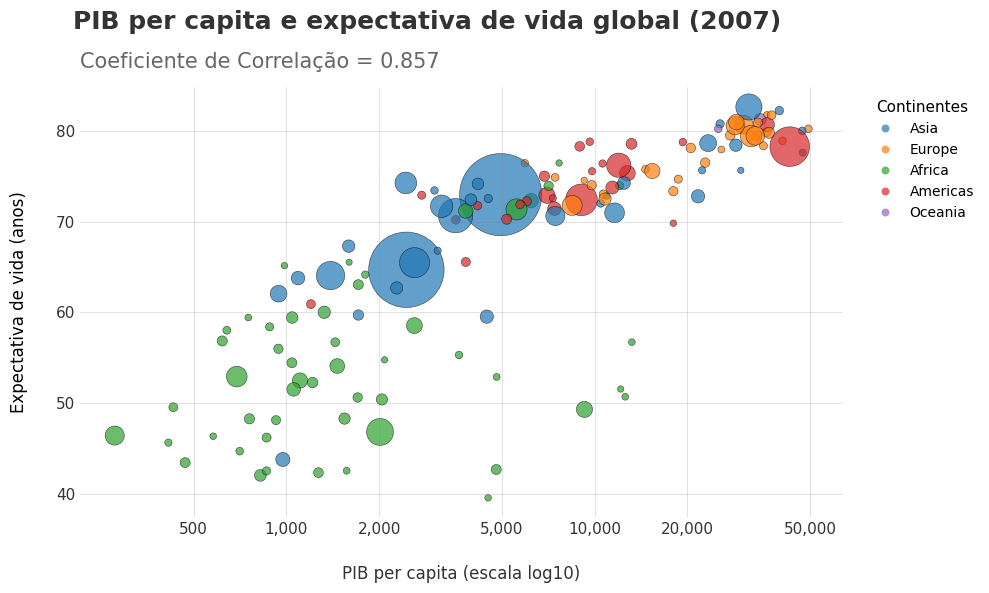

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = sns.scatterplot(
    data=gapminder_2007,
    x="gdpPercap",
    y="lifeExp",
    palette="tab10",
    edgecolor="black",
    alpha=0.7,
    hue="continent",
    size="pop",
    sizes=(20, 3500),
    ax=ax
)

ax.set_xlabel(
    xlabel="PIB per capita (escala log10)",
    fontsize=12,
    labelpad=20,
    color="#333333"
)

ax.set_ylabel(
    ylabel="Expectativa de vida (anos)",
    fontsize=12,
    labelpad=20,
)

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=11,
    labelcolor="#333333",
)

ax.set_title(
    label=f"Coeficiente de Correlação = {gdp_life_spearman.statistic:.3f}",
    fontsize=15,
    fontweight="normal",
    color="#666666",
    pad=14,
    loc="left",
)

fig.suptitle(
    t="PIB per capita e expectativa de vida global (2007)",
    fontsize=18,
    fontweight="bold",
    color="#333333",
    ha="right",
    x=0.786,
)

ax.grid(True, alpha=0.4, linewidth=0.4, color="grey")

ax.set_xscale(
    value="log",
    base=10,
)



ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter(
        "{x:,.0f}"
    )
)

ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        subs=(1, 2, 5),
    )
)

ax.xaxis.set_minor_locator(
    ticker.NullLocator(),
)

ax.legend(
    handles=continent_handles,
    labels=continent_labels,
    title="Continentes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    title_fontsize=11,
    fontsize=12,
)

sns.move_legend(
    obj=ax,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
)


sns.despine(top=True, left=True, offset=15, bottom=True,)
plt.tight_layout()
plt.show()